In [14]:
import numpy as np
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import czifile as czi

sys.path.append('../piv')
from points_df import Points

sys.path.append('../')
from diet4cola.model.tracking import load_unet_residual_model, load_unet_model, get_motion_fields, get_trajectories
from diet4cola.utils import *

In [15]:
# model = load_unet_model('../models/cola_unet')

In [16]:
model = load_unet_residual_model('../models/cola_unet_residual')

In [17]:
# experiment = '220530-E3_Out'
experiment = '220606-E5_Out'

# Load experiment and image data from CZI file
image_dir = '../data/czi/' + experiment + '.czi'
with czi.CziFile(image_dir) as image_czi:
    image_data = image_czi.asarray()

# Squeeze and extract channels
channel_red   = np.squeeze(image_data[:, :, 0, :, :, :, :, :])
channel_green = np.squeeze(image_data[:, :, 1, :, :, :, :, :])

# Normalize channels for visualization
channel_red_norm   = channel_red / channel_red.max()
channel_green_norm = channel_green / channel_green.max()

num_slices = channel_red_norm.shape[0]
print(f"Loaded {num_slices} frames from {experiment}")

# Create RGB stack for visualization
channel_blue = np.zeros(channel_green_norm.shape)
rgb_stack = np.zeros((*channel_red_norm.shape, 3), dtype=np.float32)
rgb_stack[..., 0] = channel_red_norm    # Red -> Myosin
rgb_stack[..., 1] = channel_green_norm  # Green -> Actin
rgb_stack[..., 2] = channel_blue        # Blue

Loaded 58 frames from 220606-E5_Out


In [18]:
# Create grayscale stack for ML model input (combining red and green channels)
gs_stack = channel_red_norm + channel_green_norm
gs_stack = (gs_stack - np.min(gs_stack)) / (np.max(gs_stack) - np.min(gs_stack))
print(f"Grayscale stack shape: {gs_stack.shape}")

Grayscale stack shape: (58, 512, 512)


In [19]:
# Load annotated points for the experiment
all_points = Points.from_csv('../out/points.csv')
cell_points = all_points.points_by_cell(experiment)

# Get frame range for tracking
annotated_frames = cell_points['frame'].unique()
min_frame = int(annotated_frames.min())
max_frame = int(annotated_frames.max())

# Get initial frame points (non-cut points)
initial_frame = cell_points['frame'].min()
initial_points = cell_points[cell_points['frame'] == initial_frame]
initial_points = initial_points[initial_points['cut'] == False]

# Extract point coordinates as numpy array (x, y)
points = initial_points[['x', 'y']].values
print(f"Tracking {len(points)} points from frame {initial_frame}")
print(f"Frame range: {min_frame} to {max_frame} ({max_frame - min_frame + 1} frames)")
print(f"Initial points:\n{points}")

gs_stack_subset = gs_stack[min_frame:max_frame + 1]

Tracking 12 points from frame 3
Frame range: 3 to 12 (10 frames)
Initial points:
[[405. 353.]
 [395. 330.]
 [320. 328.]
 [374. 285.]
 [334. 335.]
 [332. 306.]
 [384. 312.]
 [300. 305.]
 [381. 336.]
 [332. 347.]
 [304. 326.]
 [306. 286.]]


In [20]:
# Get trajectories using ML model on the subset of frames
trajectories, v_fields = get_trajectories(points=points, frames=gs_stack_subset, model=model)

print(f"\nTracked {len(trajectories)} trajectories")
print(f"Number of frames per trajectory: {len(trajectories[0])}")

# Display first trajectory
print(f"\nFirst trajectory (point 0):")
for i, pos in enumerate(trajectories[0][:5]):
    print(f"  Frame {min_frame + i}: ({pos[0]:.2f}, {pos[1]:.2f})")

Tracking...: 100%|██████████| 9/9 [00:00<00:00, 22989.49it/s]


Tracked 12 trajectories
Number of frames per trajectory: 10

First trajectory (point 0):
  Frame 3: (405.00, 353.00)
  Frame 4: (426.99, 357.09)
  Frame 5: (427.95, 356.24)
  Frame 6: (430.07, 356.81)
  Frame 7: (432.28, 357.22)


In [21]:
# Convert trajectories to DataFrame for easier analysis
tracked_data = []
for point_id, trajectory in trajectories.items():
    original_point_id = initial_points.iloc[point_id]['point_id']
    for frame_idx, position in enumerate(trajectory):
        tracked_data.append({
            'point_id': original_point_id,
            'frame': min_frame + frame_idx,
            'x': position[0],
            'y': position[1]
        })

tracked_df = pd.DataFrame(tracked_data)
print(f"\nTracked DataFrame shape: {tracked_df.shape}")
tracked_df.head(10)


Tracked DataFrame shape: (120, 4)


,point_id,frame,x,y
0,24,3,405.000000,353.000000
1,24,4,426.993267,357.086748
2,24,5,427.952478,356.240716
3,24,6,430.071050,356.808842
4,24,7,432.277332,357.215735
5,24,8,433.110123,356.545975
6,24,9,432.954677,355.198936
7,24,10,433.972404,355.000006
8,24,11,434.471161,355.465776
9,24,12,435.217057,355.698354


In [22]:
# Compare ML tracking with annotated points
annotated_df = cell_points[['frame', 'point_id', 'x', 'y', 'cut']].copy()
annotated_df = annotated_df[annotated_df['cut'] == False]

# Merge tracked and annotated
comparison = pd.merge(tracked_df, annotated_df, on=['frame', 'point_id'], 
                      suffixes=('_tracked', '_annotated'), how='inner')

# Calculate error
comparison['error'] = np.sqrt((comparison['x_tracked'] - comparison['x_annotated'])**2 + 
                              (comparison['y_tracked'] - comparison['y_annotated'])**2)

print(f"Comparison of {len(comparison)} point-frame pairs")
print(f"Mean error: {comparison['error'].mean():.2f} pixels")
print(f"Median error: {comparison['error'].median():.2f} pixels")
print(f"Max error: {comparison['error'].max():.2f} pixels")

comparison.head()

Comparison of 100 point-frame pairs
Mean error: 12.04 pixels
Median error: 13.36 pixels
Max error: 23.99 pixels


,point_id,frame,x_tracked,y_tracked,x_annotated,y_annotated,cut,error
0,24,3,405.000000,353.000000,405.0,353.0,False,0.000000
1,24,4,426.993267,357.086748,409.0,354.0,False,18.256113
2,24,5,427.952478,356.240716,409.0,354.0,False,19.084477
3,24,6,430.071050,356.808842,410.0,354.0,False,20.266639
4,24,7,432.277332,357.215735,410.0,354.0,False,22.508231


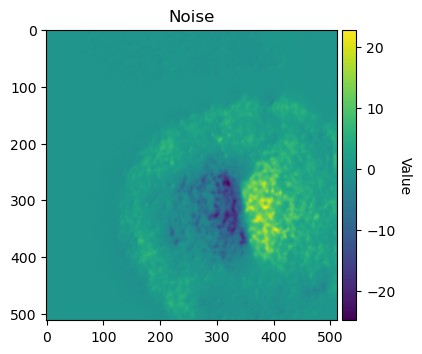

In [23]:
# Plot velocity field
from diet4cola.utils import plot_2d_array

field = v_fields[0][0]

plot_2d_array(field, cmap='viridis', min=np.min(field), max=np.max(field))

In [24]:
# Animate ML tracked vs annotated points
tracked_frames = sorted(tracked_df['frame'].unique())

fig = plt.figure(figsize=(8, 8))

def animate(i):
    plt.clf()
    frame = tracked_frames[i]
    
    # Background image - use only red channel (myosin) with grayscale colormap
    plt.imshow(channel_red_norm[frame], cmap='gray')
    
    # Annotated points
    ann_pts = annotated_df[annotated_df['frame'] == frame]
    plt.scatter(ann_pts['x'], ann_pts['y'], c='yellow', s=10, label='Annotated')
    
    # ML tracked points
    trk_pts = tracked_df[tracked_df['frame'] == frame]
    plt.scatter(trk_pts['x'], trk_pts['y'], s=50, facecolor='none', 
               edgecolors='red', linewidths=2, alpha=0.5, label='ML Tracked')
    
    plt.title(f'Frame {frame} | # Ann: {len(ann_pts)} | # ML Tracked: {len(trk_pts)}')
    plt.legend()
    plt.axis('off')

ani = animation.FuncAnimation(fig, animate, frames=len(tracked_frames), interval=300, repeat=False)

html = HTML(ani.to_jshtml())
plt.close(fig)

html

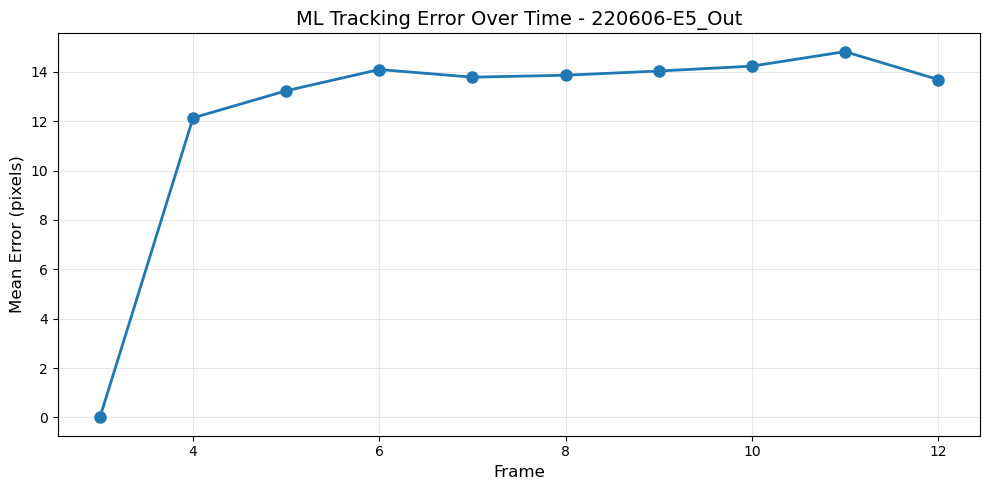

In [25]:
# Plot tracking error over time
error_per_frame = comparison.groupby('frame')['error'].mean()

plt.figure(figsize=(10, 5))
plt.plot(error_per_frame.index, error_per_frame.values, marker='o', linewidth=2, markersize=8)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Mean Error (pixels)', fontsize=12)
plt.title(f'ML Tracking Error Over Time - {experiment}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Track all cells

In [26]:
# Loop over all cells and run ML tracking
from IPython.display import clear_output

ann_points = Points.from_csv('../out/points.csv')
cellids = ann_points['cell_id'].unique()

results = []

for idx, cellid in enumerate(cellids):
    try:
        # Print progress before starting processing
        print(f'Processing {idx+1}/{len(cellids)} | Cell {cellid}...')
        
        # Load cell-specific data
        cell_points = ann_points.points_by_cell(cellid)
        if cell_points.empty:
            print(f"Skipping {cellid}: no points")
            continue
        
        # Load images
        image_dir = f'../data/czi/{cellid}.czi'
        with czi.CziFile(image_dir) as image_czi:
            image_data = image_czi.asarray()
        
        # Squeeze and extract channels
        channel_red = np.squeeze(image_data[:, :, 0, :, :, :, :, :])
        channel_green = np.squeeze(image_data[:, :, 1, :, :, :, :, :])
        
        # Normalize channels
        channel_red_norm = channel_red / channel_red.max()
        channel_green_norm = channel_green / channel_green.max()
        
        # Create grayscale stack for ML model
        gs_stack_cell = channel_red_norm + channel_green_norm
        gs_stack_cell = (gs_stack_cell - np.min(gs_stack_cell)) / (np.max(gs_stack_cell) - np.min(gs_stack_cell))
        
        # Get annotated frame range
        annotated_frames = cell_points['frame'].unique()
        min_frame = int(annotated_frames.min())
        max_frame = int(annotated_frames.max())
        num_frames = max_frame - min_frame + 1
        
        # Get initial frame points (non-cut points)
        initial_frame = cell_points['frame'].min()
        initial_points = cell_points[cell_points['frame'] == initial_frame]
        initial_points = initial_points[initial_points['cut'] == False]
        
        # Extract point coordinates
        points_array = initial_points[['x', 'y']].values
        
        print(f'  Frames {min_frame}-{max_frame} ({num_frames}) | Tracking {len(points_array)} points...')
        
        # Get subset of frames for tracking
        gs_stack_subset = gs_stack_cell[min_frame:max_frame + 1]
        
        # Run ML tracking
        trajectories, _ = get_trajectories(points=points_array, frames=gs_stack_subset, model=model)
        
        # Convert trajectories to DataFrame
        tracked_data = []
        for point_id, trajectory in trajectories.items():
            original_point_id = initial_points.iloc[point_id]['point_id']
            for frame_idx, position in enumerate(trajectory):
                tracked_data.append({
                    'point_id': original_point_id,
                    'frame': min_frame + frame_idx,
                    'x': position[0],
                    'y': position[1]
                })
        
        if tracked_data:
            tracked_df_cell = pd.DataFrame(tracked_data)
            
            # Filter cell_points to only include tracked frame range
            cell_points_filtered = cell_points[(cell_points['frame'] >= min_frame) & 
                                               (cell_points['frame'] <= max_frame)].copy()
            
            # Merge with annotations
            annotated_df_cell = cell_points_filtered[['frame', 'point_id', 'x', 'y', 'cut']].copy()
            annotated_df_cell.rename(columns={'x': 'x_ann', 'y': 'y_ann'}, inplace=True)
            
            # Left merge to keep all annotated points
            merged = pd.merge(annotated_df_cell, tracked_df_cell, on=['frame', 'point_id'], how='left')
            
            # For cut points, use annotated coordinates
            merged.loc[merged['cut'] == True, 'x'] = merged.loc[merged['cut'] == True, 'x_ann']
            merged.loc[merged['cut'] == True, 'y'] = merged.loc[merged['cut'] == True, 'y_ann']
            
            merged['cell_id'] = cellid
            merged = merged[['cell_id', 'point_id', 'frame', 'x', 'y', 'cut']]
            
            results.append(merged)
        
        clear_output(wait=True)
        
    except Exception as e:
        print(f"Error processing {cellid}: {str(e)}")
        continue

results_df = pd.concat(results, ignore_index=True)
print(f"\n✓ All done! Tracked {results_df['point_id'].nunique()} unique points across {results_df['cell_id'].nunique()} cells")
results_df.head()


✓ All done! Tracked 1525 unique points across 144 cells


,cell_id,point_id,frame,x,y,cut
0,220530-E1_Out,0,3,368.000000,192.000000,False
1,220530-E1_Out,0,4,391.075033,194.733055,False
2,220530-E1_Out,0,5,390.479956,194.353161,False
3,220530-E1_Out,0,6,390.150643,193.974477,False
4,220530-E1_Out,0,7,389.675063,193.492274,False


In [27]:
results_df.to_csv('../out/ml_tracked_points.csv', index=False)
print("Saved to ../out/ml_tracked_points.csv")

Saved to ../out/ml_tracked_points.csv
